# CODSOFT - Data Science Internship

## Task 2: Movie Rating Prediction with Python

### Objective

The objective of this project is to build a machine learning model that predicts the rating of a movie based on available movie-related features.

### Dataset

The dataset contains information about movies, including year, duration, genre, votes, and ratings. The data is used for preprocessing, feature engineering, and machine learning.

### Machine Learning Approach

A Random Forest Regression model is used to predict movie ratings. The model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [5]:
# Create a copy with the columns needed for prediction

data = df[[
    "Year",
    "Duration",
    "Genre",
    "Rating",
    "Votes"
]].copy()

data.head()

,Year,Duration,Genre,Rating,Votes
0,NaN,NaN,Drama,NaN,NaN
1,(2019),109 min,Drama,7.0,8
2,(2021),90 min,"Drama, Musical",NaN,NaN
3,(2019),110 min,"Comedy, Romance",4.4,35
4,(2010),105 min,Drama,NaN,NaN


In [6]:
# Convert Year into numeric values

data["Year"] = data["Year"].astype(str).str.extract(r"(\d{4})")[0]
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")

# Convert Duration into numeric values
data["Duration"] = data["Duration"].astype(str).str.extract(r"(\d+)")[0]
data["Duration"] = pd.to_numeric(data["Duration"], errors="coerce")

# Convert Votes into numeric values
data["Votes"] = data["Votes"].astype(str).str.replace(",", "", regex=False)
data["Votes"] = pd.to_numeric(data["Votes"], errors="coerce")

# Convert Rating into numeric values
data["Rating"] = pd.to_numeric(data["Rating"], errors="coerce")

data.head()

,Year,Duration,Genre,Rating,Votes
0,NaN,NaN,Drama,NaN,NaN
1,2019.0,109.0,Drama,7.0,8.0
2,2021.0,90.0,"Drama, Musical",NaN,NaN
3,2019.0,110.0,"Comedy, Romance",4.4,35.0
4,2010.0,105.0,Drama,NaN,NaN


In [7]:
print("Missing values before cleaning:")
print(data.isnull().sum())

data = data.dropna()

print("\nMissing values after cleaning:")
print(data.isnull().sum())

print("\nRows remaining:", len(data))

Missing values before cleaning:
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7590
dtype: int64

Missing values after cleaning:
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
dtype: int64

Rows remaining: 5820


In [8]:
# Convert Genre into separate numerical columns

genre_dummies = data["Genre"].str.get_dummies(sep=", ")

# Add genre columns to the dataset
data = pd.concat([data.drop("Genre", axis=1), genre_dummies], axis=1)

data.head()

,Year,Duration,Rating,Votes,Action,Adventure,Animation,Biography,Comedy,Crime,...,Music,Musical,Mystery,News,Romance,Sci-Fi,Sport,Thriller,War,Western
1,2019.0,109.0,7.0,8.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2019.0,110.0,4.4,35.0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
5,1997.0,147.0,4.7,827.0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
6,2005.0,142.0,7.4,1086.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
8,2012.0,82.0,5.6,326.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [9]:
# Features
X = data.drop("Rating", axis=1)

# Target
y = data["Rating"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5820, 25)
Target shape: (5820,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4656
Testing samples: 1164


In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = model.predict(X_test)

print("First 10 predicted ratings:")
print(y_pred[:10])

First 10 predicted ratings:
[7.247 5.506 6.3   7.231 4.158 5.484 7.938 7.028 7.07  5.405]


In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 3))
print("Mean Squared Error:", round(mse, 3))
print("R² Score:", round(r2, 3))

Mean Absolute Error: 0.823
Mean Squared Error: 1.169
R² Score: 0.373


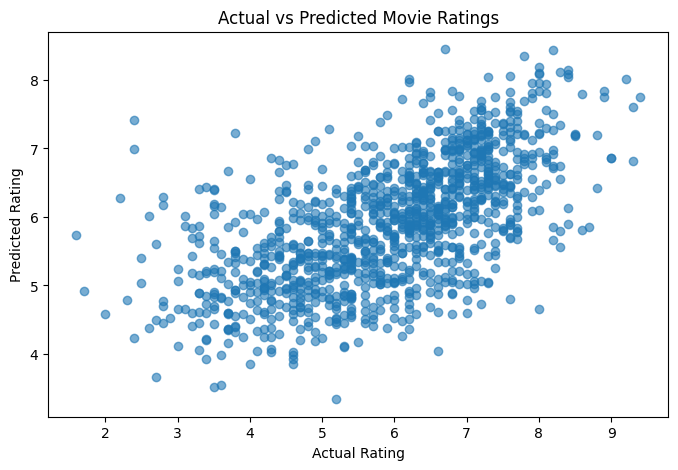

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

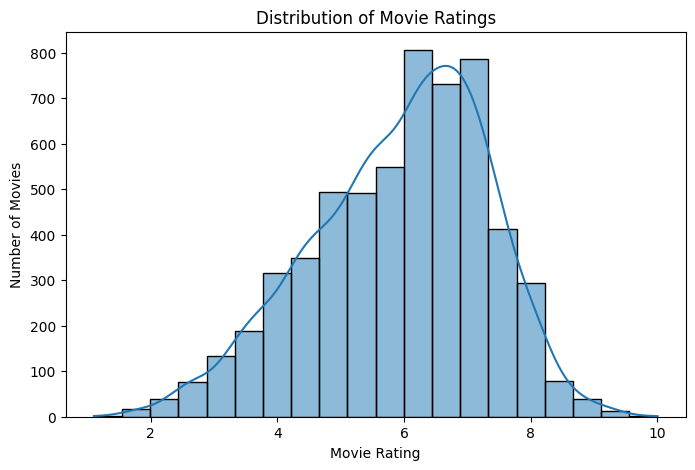

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data["Rating"], bins=20, kde=True)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Movie Rating")
plt.ylabel("Number of Movies")

plt.show()

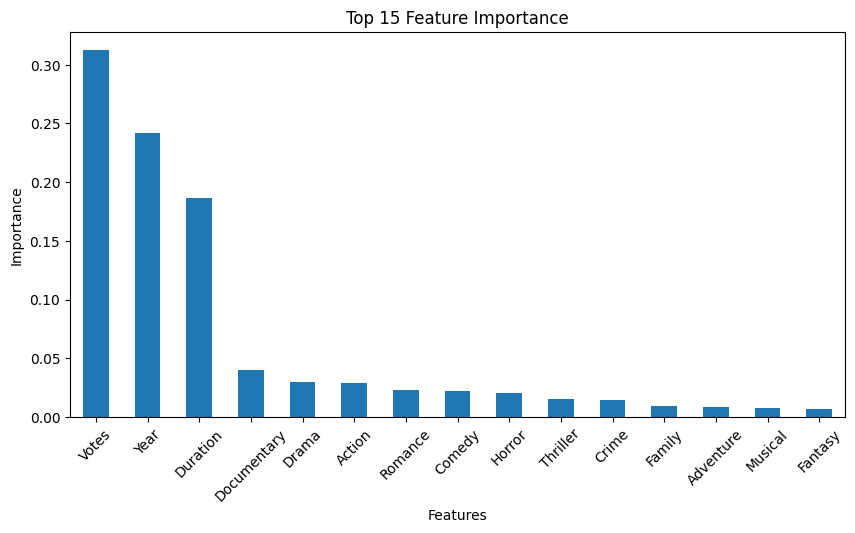

In [16]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))

importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

Conclusion

This project developed a Random Forest Regression model to predict movie ratings using historical movie data. The dataset was cleaned and prepared by converting year, duration, and votes into numerical values and transforming movie genres into numerical features.

The model was evaluated using Mean Absolute Error, Mean Squared Error, and R² Score. The visualizations helped analyze the distribution of movie ratings and the importance of different features.

This project demonstrates the use of data preprocessing, feature engineering, regression, and model evaluation for movie rating prediction.
